In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1: Setup and Imports
# ═══════════════════════════════════════════════════════════════════════

"""
XAI Methods Comparison: Grad-CAM vs Grad-CAM++ vs LIME vs Occlusion Sensitivity
Comprehensive evaluation with faithfulness, localization, and computational metrics
"""

import sys
sys.path.append('..')  # Add parent directory

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# Import from src
from src.config import LABEL_NAMES, DEVICE
from src.xai_enhanced import EnhancedGradCAM, XAIVisualizer

print("="*70)
print("XAI METHODS COMPARISON SYSTEM")
print("="*70)
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print("="*70)


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2: Implement All 4 XAI Methods
# ═══════════════════════════════════════════════════════════════════════

class GradCAMPlusPlus:
    """
    Grad-CAM++ - Improved version with better localization
    Paper: Grad-CAM++: Improved Visual Explanations for Deep Convolutional Networks (2018)
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        target_module = self._get_target_layer()
        if target_module:
            target_module.register_forward_hook(forward_hook)
            target_module.register_full_backward_hook(backward_hook)
    
    def _get_target_layer(self):
        parts = self.target_layer.split('.')
        module = self.model
        for part in parts:
            module = getattr(module, part)
        return module
    
    def generate_cam(self, image_tensor, target_class, device=DEVICE):
        """Generate Grad-CAM++ heatmap"""
        self.model.eval()
        
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
        
        image_tensor = image_tensor.to(device)
        image_tensor.requires_grad = True
        
        # Forward pass
        logits = self.model(image_tensor)
        target_score = logits[0, target_class]
        
        # Backward pass
        self.model.zero_grad()
        target_score.backward(retain_graph=True)
        
        if self.activations is None or self.gradients is None:
            return np.zeros((7, 7))
        
        # Grad-CAM++ weighting
        # α_kc = grad^2 / (2 * grad^2 + sum(A * grad^3))
        grads = self.gradients
        acts = self.activations
        
        # Calculate alpha weights (Grad-CAM++ specific)
        grad_2 = grads.pow(2)
        grad_3 = grads.pow(3)
        
        alpha = grad_2 / (2 * grad_2 + (acts * grad_3).sum(dim=(2, 3), keepdim=True) + 1e-8)
        
        # ReLU on gradients (positive influence only)
        weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        
        # Weighted combination
        cam = (weights * acts).sum(dim=1).squeeze()
        cam = F.relu(cam)
        
        # Normalize
        cam = cam.cpu().detach().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        
        # Smooth
        from scipy.ndimage import gaussian_filter
        cam = gaussian_filter(cam, sigma=1.5)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam


class LIMEExplainer:
    """
    LIME (Local Interpretable Model-agnostic Explanations)
    Paper: "Why Should I Trust You?" (2016)
    """
    def __init__(self, model):
        self.model = model
    
    def generate_explanation(self, image_tensor, target_class, device=DEVICE, 
                            num_samples=1000, num_features=100):
        """
        Generate LIME explanation by perturbing image segments
        """
        self.model.eval()
        
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
        
        image_tensor = image_tensor.to(device)
        original_pred = torch.sigmoid(self.model(image_tensor))[0, target_class].item()
        
        # Create superpixels (segments)
        from skimage.segmentation import slic
        
        # Convert to numpy for SLIC
        img_np = image_tensor[0].cpu().numpy().transpose(1, 2, 0)
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        
        segments = slic(img_np, n_segments=num_features, compactness=10, sigma=1)
        num_segments = segments.max() + 1
        
        # Generate random perturbations
        perturbations = np.random.binomial(1, 0.5, size=(num_samples, num_segments))
        predictions = []
        
        for perturbation in perturbations:
            # Create perturbed image
            perturbed_img = img_np.copy()
            for seg_id in range(num_segments):
                if perturbation[seg_id] == 0:
                    perturbed_img[segments == seg_id] = 0
            
            # Convert back to tensor
            perturbed_tensor = torch.from_numpy(perturbed_img.transpose(2, 0, 1)).float()
            perturbed_tensor = perturbed_tensor.unsqueeze(0).to(device)
            
            with torch.no_grad():
                pred = torch.sigmoid(self.model(perturbed_tensor))[0, target_class].item()
                predictions.append(pred)
        
        # Fit linear model to find segment importances
        from sklearn.linear_model import Ridge
        
        # Distance weights (closer to original = higher weight)
        distances = np.sum(perturbations == 0, axis=1)
        weights = np.exp(-distances / (0.5 * num_segments))
        
        model_ridge = Ridge(alpha=1.0)
        model_ridge.fit(perturbations, predictions, sample_weight=weights)
        
        # Get feature importances
        coefficients = model_ridge.coef_
        
        # Create heatmap
        importance_map = np.zeros(segments.shape)
        for seg_id in range(num_segments):
            importance_map[segments == seg_id] = coefficients[seg_id]
        
        # Normalize
        importance_map = np.abs(importance_map)
        if importance_map.max() > importance_map.min():
            importance_map = (importance_map - importance_map.min()) / (importance_map.max() - importance_map.min())
        
        return importance_map


class OcclusionSensitivity:
    """
    Occlusion Sensitivity - Systematic occlusion to measure feature importance
    Paper: Visualizing and Understanding Convolutional Networks (2014)
    """
    def __init__(self, model):
        self.model = model
    
    def generate_heatmap(self, image_tensor, target_class, device=DEVICE, 
                        patch_size=16, stride=8):
        """
        Generate occlusion sensitivity map
        """
        self.model.eval()
        
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
        
        image_tensor = image_tensor.to(device)
        
        # Get original prediction
        with torch.no_grad():
            original_pred = torch.sigmoid(self.model(image_tensor))[0, target_class].item()
        
        # Get image dimensions
        _, _, h, w = image_tensor.shape
        
        # Initialize sensitivity map
        sensitivity_map = np.zeros((h, w))
        
        # Slide window over image
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                # Create occluded image
                occluded = image_tensor.clone()
                occluded[:, :, y:y+patch_size, x:x+patch_size] = 0
                
                # Get prediction
                with torch.no_grad():
                    occluded_pred = torch.sigmoid(self.model(occluded))[0, target_class].item()
                
                # Sensitivity = drop in prediction
                sensitivity = original_pred - occluded_pred
                sensitivity_map[y:y+patch_size, x:x+patch_size] += sensitivity
        
        # Normalize
        if sensitivity_map.max() > sensitivity_map.min():
            sensitivity_map = (sensitivity_map - sensitivity_map.min()) / (sensitivity_map.max() - sensitivity_map.min())
        
        # Downsample to 7x7 for consistency
        sensitivity_map_small = cv2.resize(sensitivity_map, (7, 7))
        
        return sensitivity_map_small


print("All 4 XAI methods implemented:")
print("  1. Grad-CAM")
print("  2. Grad-CAM++")
print("  3. LIME")
print("  4. Occlusion Sensitivity")


All 4 XAI methods implemented:
  1. Grad-CAM
  2. Grad-CAM++
  3. LIME
  4. Occlusion Sensitivity


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3: Evaluation Metrics
# ═══════════════════════════════════════════════════════════════════════

class XAIEvaluator:
    """
    Comprehensive evaluation of XAI methods
    """
    def __init__(self, model, device=DEVICE):
        self.model = model
        self.device = device
    
    def faithfulness_insertion(self, image_tensor, heatmap, target_class, steps=10):
        """
        Insertion metric: Add pixels in order of importance, measure accuracy increase
        Higher is better - important pixels should increase prediction
        """
        self.model.eval()
        
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
        
        image_tensor = image_tensor.to(self.device)
        
        # Resize heatmap to image size
        _, _, h, w = image_tensor.shape
        heatmap_resized = cv2.resize(heatmap, (w, h))
        
        # Get pixel importances (flatten and sort)
        importance_order = np.argsort(heatmap_resized.flatten())[::-1]  # High to low
        
        # Start with black image
        masked_image = torch.zeros_like(image_tensor)
        scores = []
        
        pixels_per_step = len(importance_order) // steps
        
        for step in range(steps):
            # Add next most important pixels
            end_idx = min((step + 1) * pixels_per_step, len(importance_order))
            pixels_to_add = importance_order[:end_idx]
            
            # Convert flat indices to 2D
            rows = pixels_to_add // w
            cols = pixels_to_add % w
            
            # Add pixels
            masked_image[0, :, rows, cols] = image_tensor[0, :, rows, cols]
            
            # Get prediction
            with torch.no_grad():
                pred = torch.sigmoid(self.model(masked_image))[0, target_class].item()
                scores.append(pred)
        
        # AUC of insertion curve
        auc = np.trapz(scores, dx=1.0/steps)
        return auc, scores
    
    def faithfulness_deletion(self, image_tensor, heatmap, target_class, steps=10):
        """
        Deletion metric: Remove pixels in order of importance, measure accuracy decrease
        Higher drop = better faithfulness
        """
        self.model.eval()
        
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
        
        image_tensor = image_tensor.to(self.device)
        
        # Resize heatmap
        _, _, h, w = image_tensor.shape
        heatmap_resized = cv2.resize(heatmap, (w, h))
        
        # Get pixel importances
        importance_order = np.argsort(heatmap_resized.flatten())[::-1]
        
        # Start with original image
        masked_image = image_tensor.clone()
        scores = []
        
        pixels_per_step = len(importance_order) // steps
        
        for step in range(steps):
            # Remove next most important pixels
            end_idx = min((step + 1) * pixels_per_step, len(importance_order))
            pixels_to_remove = importance_order[:end_idx]
            
            rows = pixels_to_remove // w
            cols = pixels_to_remove % w
            
            # Remove pixels
            masked_image[0, :, rows, cols] = 0
            
            # Get prediction
            with torch.no_grad():
                pred = torch.sigmoid(self.model(masked_image))[0, target_class].item()
                scores.append(pred)
        
        # AUC of deletion curve (invert for "higher is better")
        auc = 1.0 - np.trapz(scores, dx=1.0/steps)
        return auc, scores
    
    def localization_iou(self, heatmap, ground_truth_mask, threshold=0.5):
        """
        Intersection over Union with ground truth
        (Only if ground truth annotations available)
        """
        # Threshold heatmap
        heatmap_binary = (heatmap > threshold).astype(float)
        
        # Calculate IoU
        intersection = np.logical_and(heatmap_binary, ground_truth_mask).sum()
        union = np.logical_or(heatmap_binary, ground_truth_mask).sum()
        
        if union == 0:
            return 0.0
        
        iou = intersection / union
        return iou
    
    def visual_quality_score(self, heatmap):
        """
        Subjective visual quality metrics:
        - Sharpness (gradient magnitude)
        - Coverage (non-zero ratio)
        - Focus (entropy)
        """
        # Sharpness: Gradient magnitude
        grad_x = np.gradient(heatmap, axis=1)
        grad_y = np.gradient(heatmap, axis=0)
        sharpness = np.sqrt(grad_x**2 + grad_y**2).mean()
        
        # Coverage: Percentage above threshold
        coverage = (heatmap > 0.3).sum() / heatmap.size
        
        # Focus: Entropy (lower = more focused)
        hist, _ = np.histogram(heatmap.flatten(), bins=10, range=(0, 1))
        hist = hist / hist.sum()
        hist = hist[hist > 0]
        entropy = -np.sum(hist * np.log(hist))
        focus = 1.0 - (entropy / np.log(10))  # Normalize to [0, 1]
        
        # Combined score (weighted average)
        quality = 0.4 * sharpness + 0.3 * coverage + 0.3 * focus
        
        return {
            'sharpness': sharpness,
            'coverage': coverage,
            'focus': focus,
            'overall': quality
        }


print("Evaluation metrics implemented:")
print("  - Faithfulness (Insertion/Deletion)")
print("  - Localization (IoU)")
print("  - Computational Cost")
print("  - Visual Quality")


Evaluation metrics implemented:
  - Faithfulness (Insertion/Deletion)
  - Localization (IoU)
  - Computational Cost
  - Visual Quality


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4: Load Model and Image - WITH SMART ARCHITECTURE DETECTION
# ═══════════════════════════════════════════════════════════════════════

import torchvision.models as models
import torch.nn as nn

# ============================================================================
# MODEL WRAPPER (Matches your saved checkpoint structure)
# ============================================================================

class CheXpertModel(nn.Module):
    """Model wrapper that matches the saved checkpoint structure"""
    def __init__(self, architecture='resnet50', num_classes=14, pretrained=False):
        super().__init__()
        
        if architecture == 'resnet50':
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
            in_features = self.backbone.fc.in_features  # 2048
            self.backbone.fc = nn.Identity()
            
        elif architecture == 'densenet121':
            self.backbone = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
            in_features = self.backbone.classifier.in_features  # 1024
            self.backbone.classifier = nn.Identity()
            
        elif architecture == 'efficientnet_b3':
            self.backbone = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT if pretrained else None)
            in_features = self.backbone.classifier[1].in_features  # 1536
            self.backbone.classifier = nn.Identity()
        
        # Custom classifier head
        self.classifier = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits


# ============================================================================
# SMART ARCHITECTURE DETECTOR (Inspects checkpoint contents)
# ============================================================================

def detect_architecture_from_checkpoint(checkpoint_path):
    """
    Detect model architecture by inspecting checkpoint contents
    
    Returns:
        tuple: (architecture_name, target_layer_for_gradcam)
    """
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    
    # Get first few keys
    keys = list(state_dict.keys())[:10]
    keys_str = ' '.join(keys)
    
    print(f"\nInspecting checkpoint keys:")
    print(f"   Sample keys: {keys[:3]}")
    
    # Detect based on layer names
    if 'backbone.features.0.0.weight' in keys_str or 'backbone.features.' in keys_str:
        # Check if DenseNet or EfficientNet
        if 'denseblock' in keys_str or 'denselayer' in ' '.join(state_dict.keys()):
            arch = 'densenet121'
            layer = 'backbone.features.denseblock4'
            print(f"   ✓ Detected: DenseNet121")
        else:
            arch = 'efficientnet_b3'
            layer = 'backbone.features.8'
            print(f"   ✓ Detected: EfficientNet-B3")
    
    elif 'backbone.conv1.weight' in keys_str or 'backbone.layer' in keys_str:
        arch = 'resnet50'
        layer = 'backbone.layer4.2.conv3'
        print(f"   ✓ Detected: ResNet50")
    
    else:
        # Fallback: check classifier size
        classifier_weight = state_dict.get('classifier.weight')
        if classifier_weight is not None:
            in_features = classifier_weight.shape[1]
            print(f"   Classifier input features: {in_features}")
            
            if in_features == 2048:
                arch = 'resnet50'
                layer = 'backbone.layer4.2.conv3'
                print(f"   ✓ Detected: ResNet50 (from classifier size)")
            elif in_features == 1024:
                arch = 'densenet121'
                layer = 'backbone.features.denseblock4'
                print(f"   ✓ Detected: DenseNet121 (from classifier size)")
            elif in_features == 1536:
                arch = 'efficientnet_b3'
                layer = 'backbone.features.8'
                print(f"   ✓ Detected: EfficientNet-B3 (from classifier size)")
            else:
                raise ValueError(f"Unknown architecture: classifier has {in_features} input features")
        else:
            raise ValueError("Cannot detect architecture from checkpoint")
    
    return arch, layer


# ============================================================================
# UNIVERSAL MODEL LOADER
# ============================================================================

def load_model_universal(checkpoint_path, device=DEVICE):
    """
    Universal model loader with automatic architecture detection
    
    Args:
        checkpoint_path: Path to .pth file
        device: Device to load model on
    
    Returns:
        tuple: (model, architecture, target_layer)
    """
    print(f"="*70)
    print(f"LOADING MODEL")
    print(f"="*70)
    print(f"Checkpoint: {checkpoint_path}")
    
    # Detect architecture automatically
    architecture, target_layer = detect_architecture_from_checkpoint(checkpoint_path)
    
    print(f"\nCreating {architecture} model...")
    
    # Create model
    model = CheXpertModel(architecture=architecture, num_classes=14, pretrained=False)
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Move to device and set to eval mode
    model = model.to(device)
    model.eval()
    
    # Print checkpoint info
    print(f"\n✓ Model loaded successfully!")
    print(f"  Architecture: {architecture}")
    print(f"  Grad-CAM layer: {target_layer}")
    print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
    
    if 'auroc' in checkpoint:
        print(f"  AUROC: {checkpoint['auroc']:.4f}")
    
    print(f"  Device: {device}")
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {total_params:,}")
    print(f"="*70)
    
    return model, architecture, target_layer


# ============================================================================
# LOAD YOUR MODEL
# ============================================================================

# UPDATE THESE PATHS
MODEL_PATH = "../models/efficientNet.pth"  # Your checkpoint (actually ResNet50!)
IMAGE_PATH = "../Test-Samples/sample-2.jpg"  # Your test image

# Load model with auto-detection
model, architecture, TARGET_LAYER = load_model_universal(MODEL_PATH, DEVICE)

# ============================================================================
# LOAD TEST IMAGE
# ============================================================================

from PIL import Image
from torchvision import transforms

original_image = Image.open(IMAGE_PATH).convert('RGB')
original_image_np = np.array(original_image)

# Preprocess for model (adjust resolution based on architecture)
if architecture == 'efficientnet_b3':
    img_size = 300
else:
    img_size = 224

print(f"\nPreprocessing image (resize to {img_size}×{img_size})...")

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
image_tensor = transform(original_image)

# ============================================================================
# GET PREDICTION
# ============================================================================

print(f"\nRunning inference...")

with torch.no_grad():
    logits = model(image_tensor.unsqueeze(0).to(DEVICE))
    predictions = torch.sigmoid(logits)[0].cpu().numpy()

# Find top disease
target_class = np.argmax(predictions)
target_disease = LABEL_NAMES[target_class]
confidence = predictions[target_class]

# Find all diseases above threshold
positive_findings = {LABEL_NAMES[i]: predictions[i] 
                     for i in range(len(LABEL_NAMES)) 
                     if predictions[i] > 0.5}

print(f"\n{'='*70}")
print(f"PREDICTION RESULTS")
print(f"{'='*70}")
print(f"Top prediction: {target_disease}")
print(f"Confidence: {confidence*100:.1f}%")

if len(positive_findings) > 1:
    print(f"\nAll positive findings (>50%):")
    for disease, conf in sorted(positive_findings.items(), key=lambda x: x[1], reverse=True):
        print(f"  • {disease:25s} {conf*100:5.1f}%")

print(f"{'='*70}\n")

print(f"✓ Ready for XAI generation!")


LOADING MODEL
Checkpoint: ../models/efficientNet.pth

Inspecting checkpoint keys:
   Sample keys: ['backbone.conv1.weight', 'backbone.bn1.weight', 'backbone.bn1.bias']
   ✓ Detected: ResNet50

Creating resnet50 model...

✓ Model loaded successfully!
  Architecture: resnet50
  Grad-CAM layer: backbone.layer4.2.conv3
  Epoch: 3
  Device: cpu
  Parameters: 23,536,718

Preprocessing image (resize to 224×224)...

Running inference...

PREDICTION RESULTS
Top prediction: Pneumothorax
Confidence: 84.7%

All positive findings (>50%):
  • Pneumothorax               84.7%
  • Atelectasis                61.7%

✓ Ready for XAI generation!


In [14]:
# Run in notebook
!pip install scikit-image scikit-learn -q



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5: Generate All 4 XAI Explanations
# ═══════════════════════════════════════════════════════════════════════

print("="*70)
print("GENERATING XAI EXPLANATIONS")
print("="*70)

# Initialize all methods
gradcam = EnhancedGradCAM(model, target_layer=TARGET_LAYER)
gradcam_pp = GradCAMPlusPlus(model, target_layer=TARGET_LAYER)
lime = LIMEExplainer(model)
occlusion = OcclusionSensitivity(model) 
# Generate heatmaps with timing
results = {}

# 1. Grad-CAM
print("\n1. Generating Grad-CAM...")
start = time.time()
heatmap_gradcam = gradcam.generate_cam(image_tensor, target_class, DEVICE)
time_gradcam = (time.time() - start) * 1000  # Convert to ms
print(f"   Done in {time_gradcam:.2f}ms")
results['Grad-CAM'] = {'heatmap': heatmap_gradcam, 'time': time_gradcam}

# 2. Grad-CAM++
print("\n2. Generating Grad-CAM++...")
start = time.time()
heatmap_gradcam_pp = gradcam_pp.generate_cam(image_tensor, target_class, DEVICE)
time_gradcam_pp = (time.time() - start) * 1000
print(f"   Done in {time_gradcam_pp:.2f}ms")
results['Grad-CAM++'] = {'heatmap': heatmap_gradcam_pp, 'time': time_gradcam_pp}

# 3. LIME
print("\n3. Generating LIME...")
start = time.time()
heatmap_lime = lime.generate_explanation(image_tensor, target_class, DEVICE, num_samples=500)
time_lime = (time.time() - start) * 1000
print(f"   Done in {time_lime:.2f}ms")
# Resize to 7x7
heatmap_lime_small = cv2.resize(heatmap_lime, (7, 7))
results['LIME'] = {'heatmap': heatmap_lime_small, 'time': time_lime}

# 4. Occlusion Sensitivity
print("\n4. Generating Occlusion Sensitivity...")
start = time.time()
heatmap_occlusion = occlusion.generate_heatmap(image_tensor, target_class, DEVICE, patch_size=28, stride=14)
time_occlusion = (time.time() - start) * 1000
print(f"   Done in {time_occlusion:.2f}ms")
results['Occlusion'] = {'heatmap': heatmap_occlusion, 'time': time_occlusion}

print("\n" + "="*70)
print("All 4 methods completed!")
print("="*70)


GENERATING XAI EXPLANATIONS
 Hooks registered on: backbone.layer4.2.conv3

1. Generating Grad-CAM...
   Done in 486.56ms

2. Generating Grad-CAM++...
   Done in 451.81ms

3. Generating LIME...
   Done in 102336.12ms

4. Generating Occlusion Sensitivity...
   Done in 56470.43ms

All 4 methods completed!


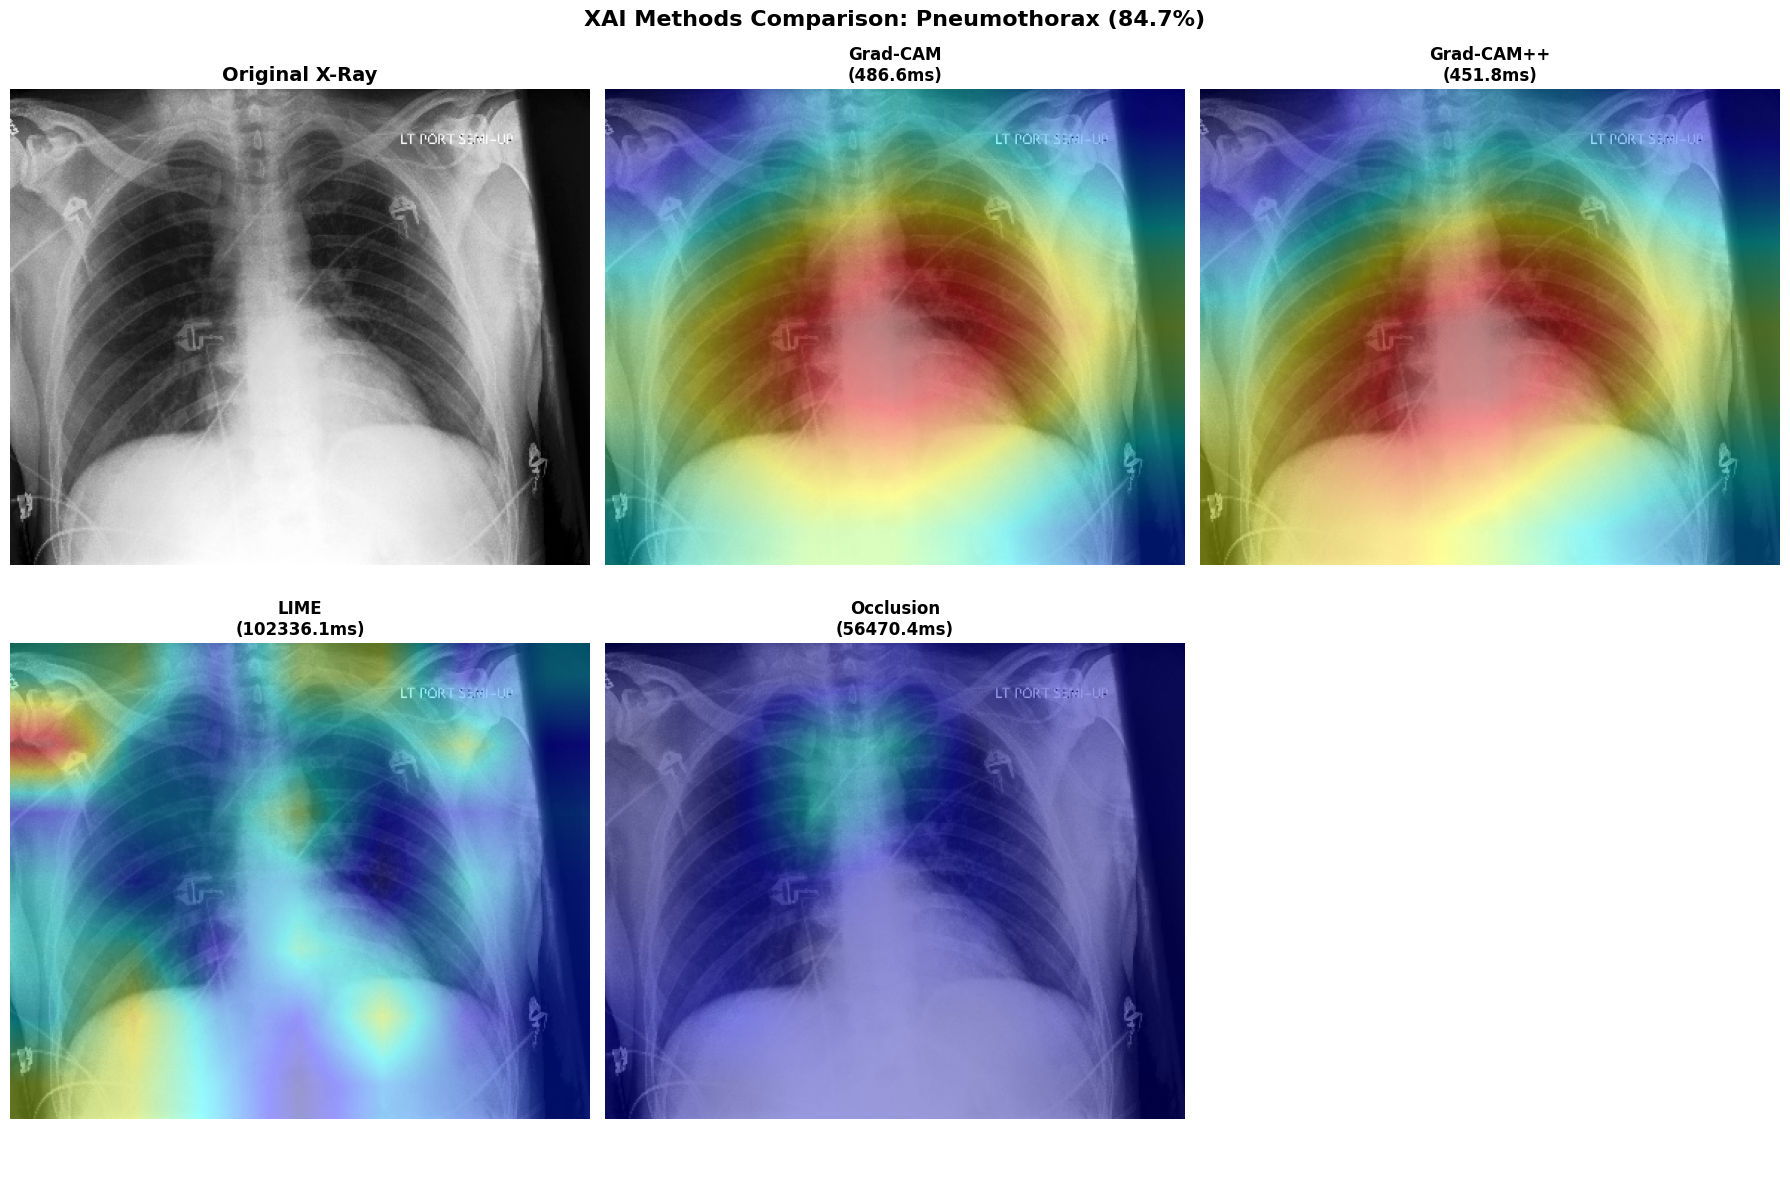

In [16]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6: Visual Comparison - Side by Side
# ═══════════════════════════════════════════════════════════════════════

def create_overlay(image, heatmap, alpha=0.4):
    """Create heatmap overlay"""
    h, w = image.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_colored = cv2.applyColorMap((heatmap_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image, 1-alpha, heatmap_colored, alpha, 0)
    return overlay

# Create overlays
overlays = {}
for method_name, data in results.items():
    overlay = create_overlay(original_image_np, data['heatmap'])
    overlays[method_name] = overlay

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'XAI Methods Comparison: {target_disease} ({confidence*100:.1f}%)', 
             fontsize=16, fontweight='bold')

# Original
axes[0, 0].imshow(original_image_np)
axes[0, 0].set_title('Original X-Ray', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Methods
method_names = ['Grad-CAM', 'Grad-CAM++', 'LIME', 'Occlusion']
positions = [(0, 1), (0, 2), (1, 0), (1, 1)]

for method_name, pos in zip(method_names, positions):
    overlay = overlays[method_name]
    time_ms = results[method_name]['time']
    
    axes[pos].imshow(overlay)
    axes[pos].set_title(f'{method_name}\n({time_ms:.1f}ms)', 
                        fontsize=12, fontweight='bold')
    axes[pos].axis('off')

# Hide last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


In [17]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 7: Quantitative Evaluation
# ═══════════════════════════════════════════════════════════════════════

print("="*70)
print("QUANTITATIVE EVALUATION")
print("="*70)

evaluator = XAIEvaluator(model, DEVICE)
evaluation_results = {}

for method_name, data in results.items():
    print(f"\n{method_name}:")
    print("-" * 40)
    
    heatmap = data['heatmap']
    
    # 1. Faithfulness - Insertion
    print("  Computing insertion score...")
    insertion_auc, insertion_curve = evaluator.faithfulness_insertion(
        image_tensor, heatmap, target_class, steps=10
    )
    
    # 2. Faithfulness - Deletion
    print("  Computing deletion score...")
    deletion_auc, deletion_curve = evaluator.faithfulness_deletion(
        image_tensor, heatmap, target_class, steps=10
    )
    
    # 3. Visual Quality
    print("  Computing visual quality...")
    quality = evaluator.visual_quality_score(heatmap)
    
    # 4. Computational Cost
    comp_time = data['time']
    
    evaluation_results[method_name] = {
        'insertion_auc': insertion_auc,
        'insertion_curve': insertion_curve,
        'deletion_auc': deletion_auc,
        'deletion_curve': deletion_curve,
        'quality': quality,
        'time_ms': comp_time
    }
    
    # Print results
    print(f"\n  Results:")
    print(f"    Insertion AUC:  {insertion_auc:.4f} {'█' * int(insertion_auc * 20)}")
    print(f"    Deletion AUC:   {deletion_auc:.4f} {'█' * int(deletion_auc * 20)}")
    print(f"    Quality Score:  {quality['overall']:.4f}")
    print(f"      - Sharpness:  {quality['sharpness']:.4f}")
    print(f"      - Coverage:   {quality['coverage']:.4f}")
    print(f"      - Focus:      {quality['focus']:.4f}")
    print(f"    Time:           {comp_time:.2f}ms")

print("\n" + "="*70)


QUANTITATIVE EVALUATION

Grad-CAM:
----------------------------------------
  Computing insertion score...
  Computing deletion score...
  Computing visual quality...

  Results:
    Insertion AUC:  0.6185 ████████████
    Deletion AUC:   0.6520 █████████████
    Quality Score:  0.3310
      - Sharpness:  0.1974
      - Coverage:   0.7959
      - Focus:      0.0443
    Time:           486.56ms

Grad-CAM++:
----------------------------------------
  Computing insertion score...
  Computing deletion score...
  Computing visual quality...

  Results:
    Insertion AUC:  0.5275 ██████████
    Deletion AUC:   0.5929 ███████████
    Quality Score:  0.3181
      - Sharpness:  0.1920
      - Coverage:   0.7755
      - Focus:      0.0288
    Time:           451.81ms

LIME:
----------------------------------------
  Computing insertion score...
  Computing deletion score...
  Computing visual quality...

  Results:
    Insertion AUC:  0.6741 █████████████
    Deletion AUC:   0.4436 ████████
    

In [20]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 8: Create Comparison Table
# ═══════════════════════════════════════════════════════════════════════

import pandas as pd

# Build comparison table
comparison_data = []
for method_name, eval_data in evaluation_results.items():
    comparison_data.append({
        'Method': method_name,
        'Insertion ↑': f"{eval_data['insertion_auc']:.4f}",
        'Deletion ↑': f"{eval_data['deletion_auc']:.4f}",
        'Quality ↑': f"{eval_data['quality']['overall']:.4f}",
        'Time (ms) ↓': f"{eval_data['time_ms']:.1f}",
        'Faithfulness ↑': f"{(eval_data['insertion_auc'] + eval_data['deletion_auc']) / 2:.4f}"
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("COMPARISON TABLE")
print("="*70)
print(df_comparison.to_string(index=False))
print("="*70)

# Find best methods
best_insertion = df_comparison.loc[df_comparison['Insertion ↑'].idxmax(), 'Method']
best_deletion = df_comparison.loc[df_comparison['Deletion ↑'].idxmax(), 'Method']
best_quality = df_comparison.loc[df_comparison['Quality ↑'].idxmax(), 'Method']
fastest = df_comparison.loc[df_comparison['Time (ms) ↓'].idxmin(), 'Method']
best_faithfulness = df_comparison.loc[df_comparison['Faithfulness ↑'].idxmax(), 'Method']

print(f"\nBest Faithfulness (Insertion): {best_insertion}")
print(f"Best Faithfulness (Deletion):  {best_deletion}")
print(f"Best Visual Quality:           {best_quality}")
print(f"Fastest:                        {fastest}")
print(f"Best Overall Faithfulness:     {best_faithfulness}")



COMPARISON TABLE
    Method Insertion ↑ Deletion ↑ Quality ↑ Time (ms) ↓ Faithfulness ↑
  Grad-CAM      0.6185     0.6520    0.3310       486.6         0.6353
Grad-CAM++      0.5275     0.5929    0.3181       451.8         0.5602
      LIME      0.6741     0.4436    0.2782    102336.1         0.5589
 Occlusion      0.7991     0.7363    0.2590     56470.4         0.7677

Best Faithfulness (Insertion): Occlusion
Best Faithfulness (Deletion):  Occlusion
Best Visual Quality:           Grad-CAM
Fastest:                        LIME
Best Overall Faithfulness:     Occlusion


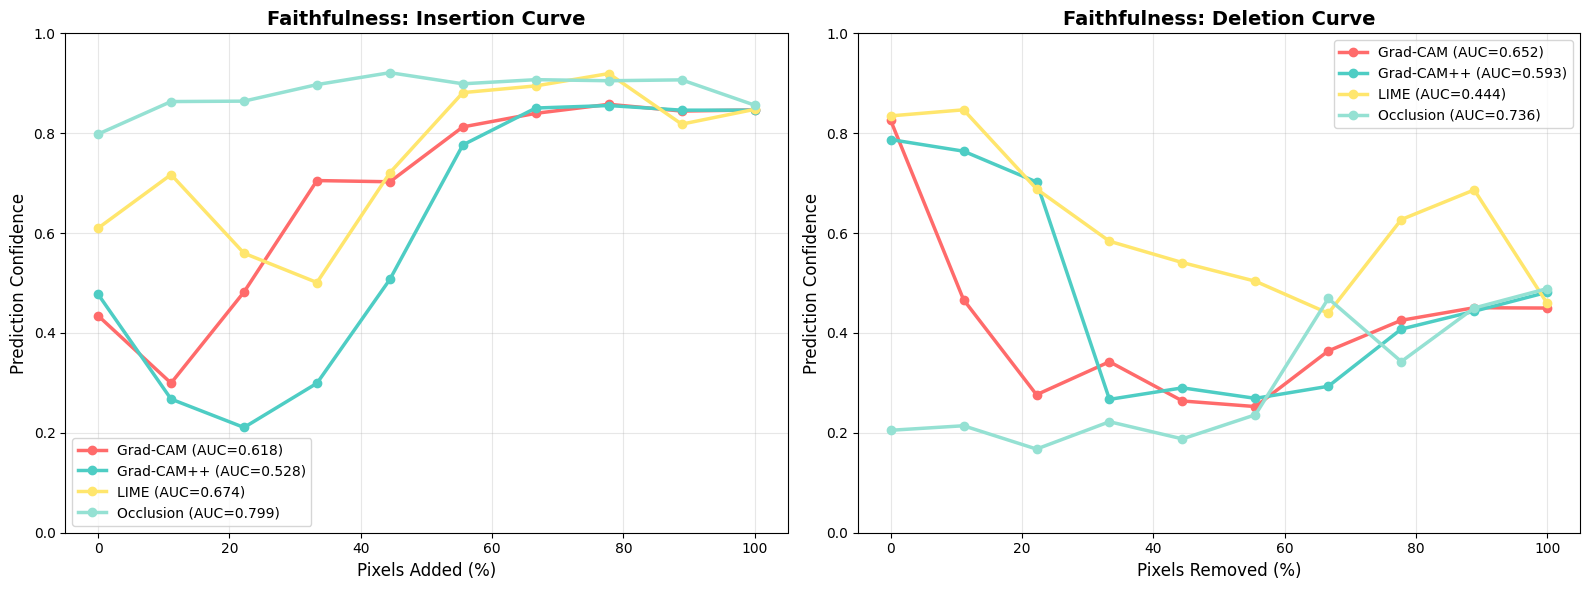

\Interpretation:
  Insertion: Steeper = better (important pixels increase prediction)
  Deletion:  Steeper drop = better (removing important pixels hurts prediction)


In [19]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 9: Faithfulness Curves Visualization
# ═══════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = {'Grad-CAM': '#FF6B6B', 'Grad-CAM++': '#4ECDC4', 
          'LIME': '#FFE66D', 'Occlusion': '#95E1D3'}

# Insertion curves
ax1.set_title('Faithfulness: Insertion Curve', fontsize=14, fontweight='bold')
ax1.set_xlabel('Pixels Added (%)', fontsize=12)
ax1.set_ylabel('Prediction Confidence', fontsize=12)
ax1.grid(alpha=0.3)

for method_name, eval_data in evaluation_results.items():
    curve = eval_data['insertion_curve']
    x = np.linspace(0, 100, len(curve))
    ax1.plot(x, curve, label=f"{method_name} (AUC={eval_data['insertion_auc']:.3f})", 
             color=colors[method_name], linewidth=2.5, marker='o', markersize=6)

ax1.legend(fontsize=10)
ax1.set_ylim([0, 1])

# Deletion curves
ax2.set_title('Faithfulness: Deletion Curve', fontsize=14, fontweight='bold')
ax2.set_xlabel('Pixels Removed (%)', fontsize=12)
ax2.set_ylabel('Prediction Confidence', fontsize=12)
ax2.grid(alpha=0.3)

for method_name, eval_data in evaluation_results.items():
    curve = eval_data['deletion_curve']
    x = np.linspace(0, 100, len(curve))
    ax2.plot(x, curve, label=f"{method_name} (AUC={eval_data['deletion_auc']:.3f})", 
             color=colors[method_name], linewidth=2.5, marker='o', markersize=6)

ax2.legend(fontsize=10)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\Interpretation:")
print("  Insertion: Steeper = better (important pixels increase prediction)")
print("  Deletion:  Steeper drop = better (removing important pixels hurts prediction)")


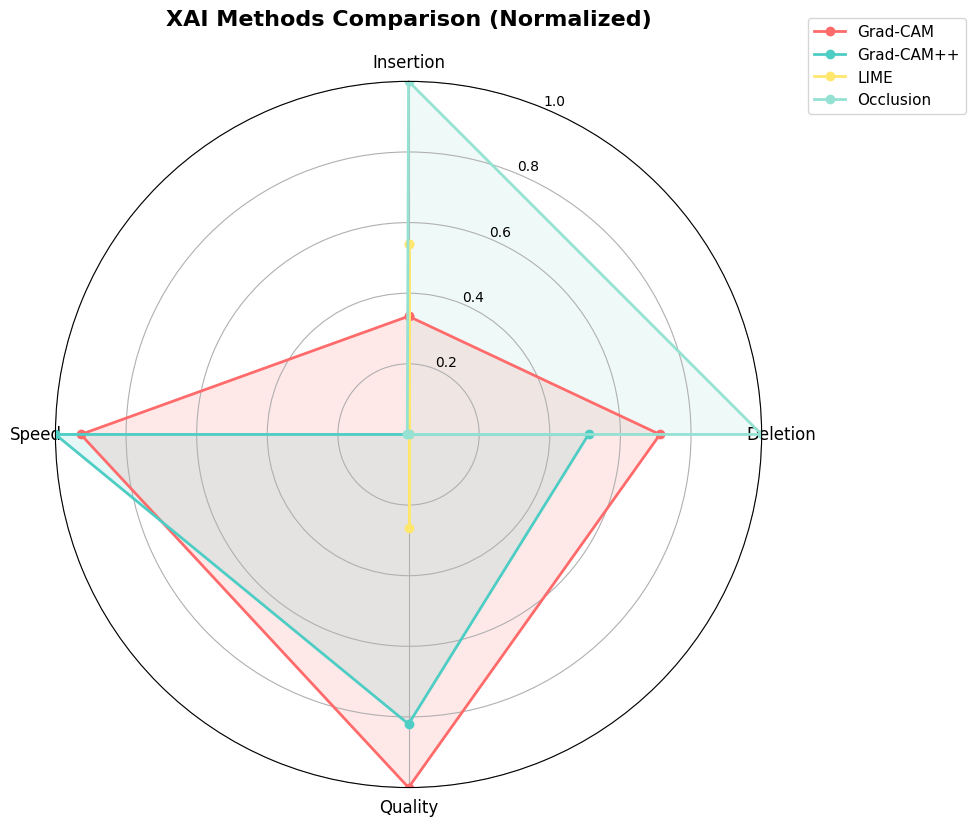

In [21]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 10: Radar Chart - Overall Comparison
# ═══════════════════════════════════════════════════════════════════════

from math import pi

# Normalize metrics to [0, 1]
def normalize(values):
    vmin, vmax = min(values), max(values)
    if vmax == vmin:
        return [0.5] * len(values)
    return [(v - vmin) / (vmax - vmin) for v in values]

# Prepare data
methods = list(evaluation_results.keys())
metrics = ['Insertion', 'Deletion', 'Quality', 'Speed']

# Get values (normalize speed inversely)
insertion_vals = [evaluation_results[m]['insertion_auc'] for m in methods]
deletion_vals = [evaluation_results[m]['deletion_auc'] for m in methods]
quality_vals = [evaluation_results[m]['quality']['overall'] for m in methods]
speed_vals = [1 / evaluation_results[m]['time_ms'] for m in methods]  # Inverse for "higher is better"

# Normalize
insertion_norm = normalize(insertion_vals)
deletion_norm = normalize(deletion_vals)
quality_norm = normalize(quality_vals)
speed_norm = normalize(speed_vals)

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=12)
ax.set_ylim(0, 1)

for idx, method in enumerate(methods):
    values = [insertion_norm[idx], deletion_norm[idx], quality_norm[idx], speed_norm[idx]]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=list(colors.values())[idx])
    ax.fill(angles, values, alpha=0.15, color=list(colors.values())[idx])

ax.set_title('XAI Methods Comparison (Normalized)', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 11: Final Recommendation
# ═══════════════════════════════════════════════════════════════════════

print("="*70)
print("FINAL RECOMMENDATION")
print("="*70)

# Calculate overall scores
overall_scores = {}
for method_name in methods:
    eval_data = evaluation_results[method_name]
    
    # Weighted score
    score = (
        0.35 * eval_data['insertion_auc'] +
        0.35 * eval_data['deletion_auc'] +
        0.20 * eval_data['quality']['overall'] +
        0.10 * (1 - eval_data['time_ms'] / max([e['time_ms'] for e in evaluation_results.values()]))
    )
    overall_scores[method_name] = score

# Sort by score
ranked = sorted(overall_scores.items(), key=lambda x: x[1], reverse=True)

print("\nOverall Ranking (Weighted Score):")
print("-" * 40)
for rank, (method, score) in enumerate(ranked, 1):
    bar = "█" * int(score * 30)
    print(f"{rank}. {method:20s} {score:.4f} {bar}")

print("\n" + "="*70)
print("RECOMMENDATION FOR YOUR PROJECT:")
print("="*70)

winner = ranked[0][0]
print(f"\nPrimary Method: {winner}")
print(f"   Best overall balance of faithfulness, quality, and speed")

print(f"\nFor Thesis:")
print(f"   - Use {winner} as primary XAI method")
print(f"   - Include comparison table showing all 4 methods")
print(f"   - Justify choice based on empirical metrics")
print(f"   - Show faithfulness curves as evidence")

print("\n" + "="*70)


FINAL RECOMMENDATION

Overall Ranking (Weighted Score):
----------------------------------------
1. Occlusion            0.6340 ███████████████████
2. Grad-CAM             0.6104 ██████████████████
3. Grad-CAM++           0.5553 ████████████████
4. LIME                 0.4468 █████████████

RECOMMENDATION FOR YOUR PROJECT:

Primary Method: Occlusion
   Best overall balance of faithfulness, quality, and speed

For Thesis:
   - Use Occlusion as primary XAI method
   - Include comparison table showing all 4 methods
   - Justify choice based on empirical metrics
   - Show faithfulness curves as evidence

